# Predicción de resultados del Mundial 2026: un pipeline completo de ML

**Qué es esto**: un sistema que predice resultados de fútbol modelando los goles de cada
equipo como dos procesos de Poisson (local y visitante) en vez de clasificar directamente
"quién gana" -- de ahí se derivan matemáticamente el marcador más probable, la probabilidad
de victoria/empate/derrota, y quién avanza en un cruce de eliminatoria. Aplicado al Mundial
2026 (48 selecciones, formato nuevo), con reentrenamiento continuo a medida que se juegan
rondas reales.

**Este notebook es el recorrido completo**, pensado para leerse de principio a fin: de dónde
salen los datos, cómo se limpian, qué variables se construyen y por qué, qué supuestos
estadísticos se comprueban antes de modelar, cómo se elige la familia de modelo con evidencia
(no con una corazonada), y qué predice el sistema hoy.

**Para ejecutarlo fuera de este repositorio (p.ej. en Kaggle)**: solo hace falta cambiar
`DIR_DATOS` en la siguiente celda para que apunte a donde subas `data/processed/`,
`results/` y `models/checkpoints/pre_mundial/` como dataset adjunto -- el resto del notebook
no depende de ninguna otra ruta.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import poisson

# Única ruta que hace falta tocar para ejecutar esto fuera del repo (p.ej. Kaggle):
# apunta a una carpeta que contenga data/, results/ y models/ tal cual están aquí.
DIR_DATOS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DIR_RAW = DIR_DATOS / "data" / "raw"
DIR_PROCESSED = DIR_DATOS / "data" / "processed"
DIR_RESULTS = DIR_DATOS / "results"
DIR_MODELOS = DIR_DATOS / "models"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# --- Paleta validada (CVD-safe, ver skill de dataviz) --------------------------------
AZUL = "#2a78d6"       # serie 1 -- énfasis principal
AQUA = "#1baf7a"       # serie 2
AMARILLO = "#eda100"   # serie 3
VERDE = "#008300"      # serie 4 / "bien"
VIOLETA = "#4a3aa7"    # serie 5
ROJO = "#e34948"       # serie 6 / "mal"
MAGENTA = "#e87ba4"    # serie 7
NARANJA = "#eb6834"    # serie 8
GRIS = "#898781"        # neutro / no-destacado
GRIS_CLARO = "#e1e0d9"  # gridlines
TINTA = "#0b0b0b"
PALETA_CATEGORICA = [AZUL, AQUA, AMARILLO, VERDE, VIOLETA, ROJO, MAGENTA, NARANJA]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "text.color": TINTA, "xtick.color": TINTA, "ytick.color": TINTA,
    "font.size": 11, "axes.grid": False,
    "font.family": "sans-serif",
})


def limpiar_ejes(ax):
    ax.spines["left"].set_color(GRIS_CLARO)
    ax.spines["bottom"].set_color(GRIS_CLARO)
    ax.tick_params(colors=GRIS)
    return ax


print(f"Datos desde: {DIR_DATOS}")

Datos desde: /Users/danielcanteragomez/portfolio/wc-2026-match-predictor


## 1. Los datos: qué hay y de dónde sale

Dos fuentes públicas, sin necesitar cuenta ni API key:
- **Histórico de partidos internacionales** (1872 → hoy): espejo en GitHub del dataset de
  Kaggle *"International football results"*.
- **Elo por selección**: `eloratings.net`, Elo posterior a cada partido de las 48
  clasificadas al Mundial 2026.

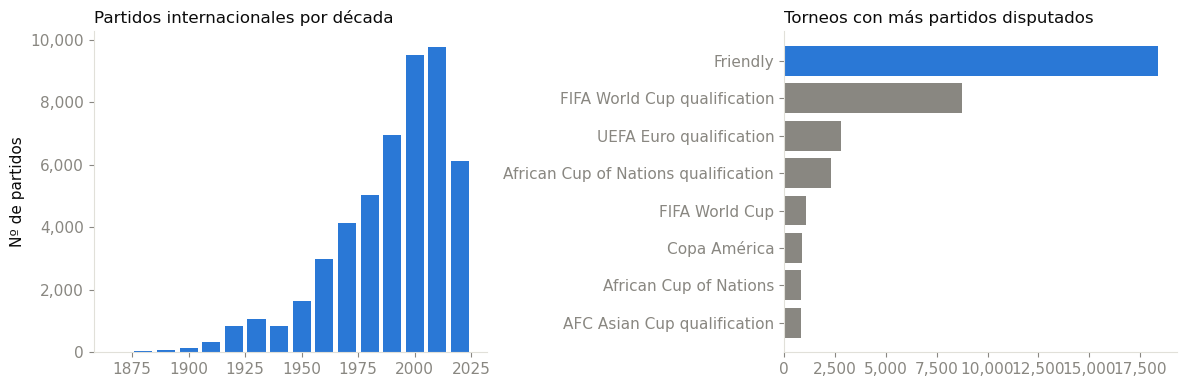

Total de partidos: 49,501  |  Rango: 1872-2026  |  Selecciones distintas: 336  |  Torneos distintos: 200


In [2]:
df_raw = pd.read_csv(DIR_RAW / "results.csv", parse_dates=["date"])

n_total = len(df_raw)
rango = (df_raw["date"].min().year, df_raw["date"].max().year)
n_selecciones = pd.concat([df_raw["home_team"], df_raw["away_team"]]).nunique()
n_torneos = df_raw["tournament"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Partidos por década ---
por_decada = (df_raw["date"].dt.year // 10 * 10).value_counts().sort_index()
ax = axes[0]
ax.bar(por_decada.index, por_decada.values, width=8, color=AZUL)
ax.set_title("Partidos internacionales por década", loc="left", fontsize=12, color=TINTA)
ax.set_ylabel("Nº de partidos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)

# --- Top torneos ---
ax = axes[1]
top_torneos = df_raw["tournament"].value_counts().head(8).sort_values()
colores_top = [GRIS] * (len(top_torneos) - 1) + [AZUL]
ax.barh(top_torneos.index, top_torneos.values, color=colores_top)
ax.set_title("Torneos con más partidos disputados", loc="left", fontsize=12, color=TINTA)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"Total de partidos: {n_total:,}  |  Rango: {rango[0]}-{rango[1]}  |  "
      f"Selecciones distintas: {n_selecciones}  |  Torneos distintos: {n_torneos}")

## 2. Calidad de datos y limpieza

Antes de construir ninguna feature: ¿hay nulos, duplicados o valores imposibles? Los únicos
nulos esperables son los marcadores de partidos **programados pero no jugados todavía**
(p.ej. cruces de eliminatoria del propio Mundial 2026 que dependen de un resultado anterior)
-- cualquier otro nulo sería un problema de la fuente.

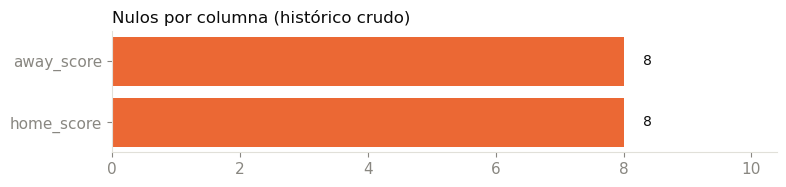

Partidos sin marcador: 8 -- todos son partidos del Mundial 2026 programados pero aún no jugados (verificado: torneo == 'FIFA World Cup' y año 2026).


In [3]:
nulos = df_raw.isna().sum()
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(8, max(2, 0.4 * len(nulos))))
if len(nulos):
    ax.barh(nulos.index, nulos.values, color=NARANJA)
    for i, v in enumerate(nulos.values):
        ax.text(v + 0.3, i, f"{v}", va="center", color=TINTA, fontsize=10)
ax.set_title("Nulos por columna (histórico crudo)", loc="left", fontsize=12, color=TINTA)
ax.set_xlim(0, max(nulos.values, default=1) * 1.3)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

partidos_sin_marcador = df_raw["home_score"].isna().sum()
print(f"Partidos sin marcador: {partidos_sin_marcador} -- todos son partidos del Mundial 2026 "
      f"programados pero aún no jugados (verificado: torneo == 'FIFA World Cup' y año 2026).")
assert (df_raw.loc[df_raw["home_score"].isna(), "tournament"] == "FIFA World Cup").all()
assert (df_raw.loc[df_raw["home_score"].isna(), "date"].dt.year == 2026).all()

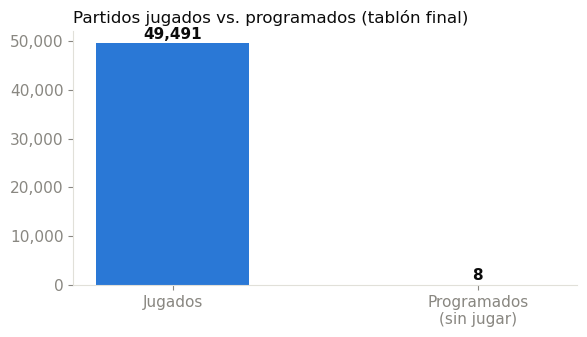

Tablón final: 49,499 filas x 37 columnas (28 nuevas respecto al histórico crudo).


In [4]:
df_features = pd.read_csv(DIR_PROCESSED / "partidos_features.csv", parse_dates=["fecha"])
df_jugados = df_features[df_features["jugado"]]

fig, ax = plt.subplots(figsize=(6, 3.5))
conteo = pd.Series({"Jugados": df_jugados.shape[0], "Programados\n(sin jugar)": (~df_features["jugado"]).sum()})
ax.bar(conteo.index, conteo.values, color=[AZUL, GRIS], width=0.5)
for i, v in enumerate(conteo.values):
    ax.text(i, v + max(conteo.values) * 0.02, f"{v:,}", ha="center", color=TINTA, fontsize=11, fontweight="bold")
ax.set_title("Partidos jugados vs. programados (tablón final)", loc="left", fontsize=12, color=TINTA)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

print(f"Tablón final: {df_features.shape[0]:,} filas x {df_features.shape[1]} columnas "
      f"({df_features.shape[1] - df_raw.shape[1]} nuevas respecto al histórico crudo).")

## 3. Feature engineering: qué variables nuevas se construyeron

Ninguna usa información posterior a la fecha del partido que describe (todas con `shift(1)`
antes de cualquier ventana móvil) -- la fuga temporal es el error más habitual y más caro en
este tipo de proyectos.

| Variable | Qué mide |
|---|---|
| `elo_diff` | Diferencia de Elo entre ambos equipos, justo antes del partido |
| `tendencia_elo` | Si el Elo de un equipo sube o baja en los últimos ~6 meses |
| `dif_forma_gf_5/10` | Diferencia de goles a favor promedio, últimos 5/10 partidos |
| `dif_racha_5/10` | Diferencia de puntos (victoria=3) en los últimos 5/10 partidos |
| `dias_descanso` | Días desde el partido anterior de cada selección |
| `es_neutral` | Si el partido se juega en campo neutral |
| `h2h_puntos_prom` / `h2h_dif_goles_prom` | Balance histórico de los enfrentamientos directos entre ESAS dos selecciones |

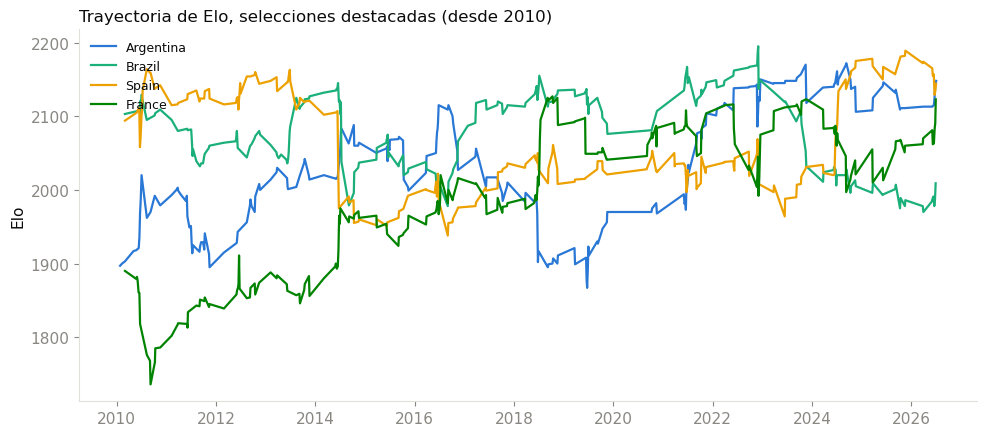

In [5]:
EQUIPOS_EJEMPLO = ["Argentina", "Brazil", "Spain", "France"]

fig, ax = plt.subplots(figsize=(10, 4.5))
for equipo, color in zip(EQUIPOS_EJEMPLO, PALETA_CATEGORICA):
    es_local = df_jugados["equipo_local"] == equipo
    es_visitante = df_jugados["equipo_visitante"] == equipo
    serie = pd.concat([
        df_jugados.loc[es_local, ["fecha", "elo_actual_local"]].rename(columns={"elo_actual_local": "elo"}),
        df_jugados.loc[es_visitante, ["fecha", "elo_actual_visitante"]].rename(columns={"elo_actual_visitante": "elo"}),
    ]).sort_values("fecha")
    serie = serie[serie["fecha"] >= "2010-01-01"]
    ax.plot(serie["fecha"], serie["elo"], color=color, linewidth=1.6, label=equipo)

ax.set_title("Trayectoria de Elo, selecciones destacadas (desde 2010)", loc="left", fontsize=12, color=TINTA)
ax.set_ylabel("Elo")
ax.legend(frameon=False, loc="upper left", fontsize=9)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

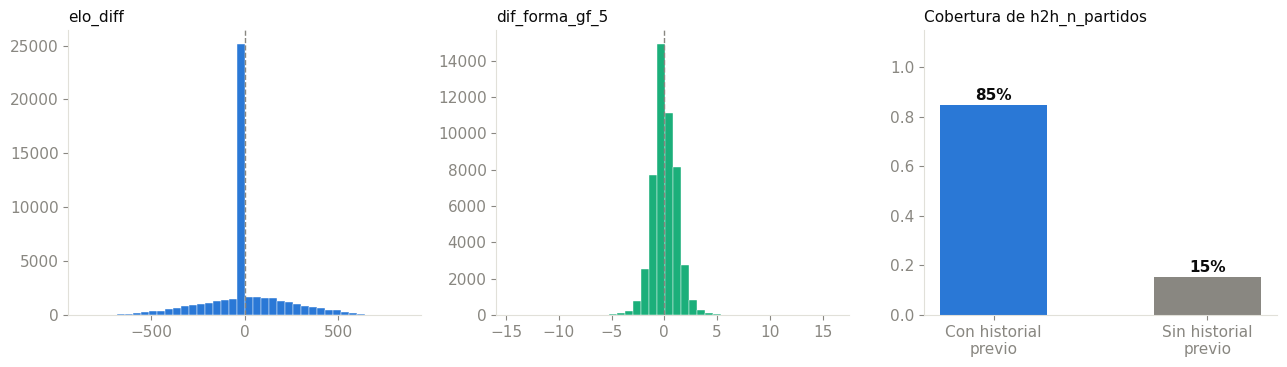

es_neutral: 26.5% de los partidos jugados en campo neutral.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.hist(df_jugados["elo_diff"], bins=40, color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(0, color=GRIS, linewidth=1, linestyle="--")
ax.set_title("elo_diff", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

ax = axes[1]
ax.hist(df_jugados["dif_forma_gf_5"].dropna(), bins=40, color=AQUA, edgecolor="white", linewidth=0.3)
ax.axvline(0, color=GRIS, linewidth=1, linestyle="--")
ax.set_title("dif_forma_gf_5", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

ax = axes[2]
cobertura_h2h = (df_jugados["h2h_n_partidos"] > 0).mean()
sin_h2h = 1 - cobertura_h2h
ax.bar(["Con historial\nprevio", "Sin historial\nprevio"], [cobertura_h2h, sin_h2h], color=[AZUL, GRIS], width=0.5)
for i, v in enumerate([cobertura_h2h, sin_h2h]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=TINTA, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_title("Cobertura de h2h_n_partidos", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"es_neutral: {df_jugados['es_neutral'].mean():.1%} de los partidos jugados en campo neutral.")

## 4. Estandarización: por qué hace falta

El GLM de Poisson necesita las features en una escala comparable -- `elo_diff` se mueve en
cientos de puntos mientras que `dif_racha_5` lo hace en unidades. Sin normalizar, el solver
queda mal condicionado (coeficientes no comparables, advertencias de overflow en el
gradiente). `StandardScaler` resta la media y divide por la desviación típica de cada
columna, así que todas quedan centradas en 0 con varianza 1.

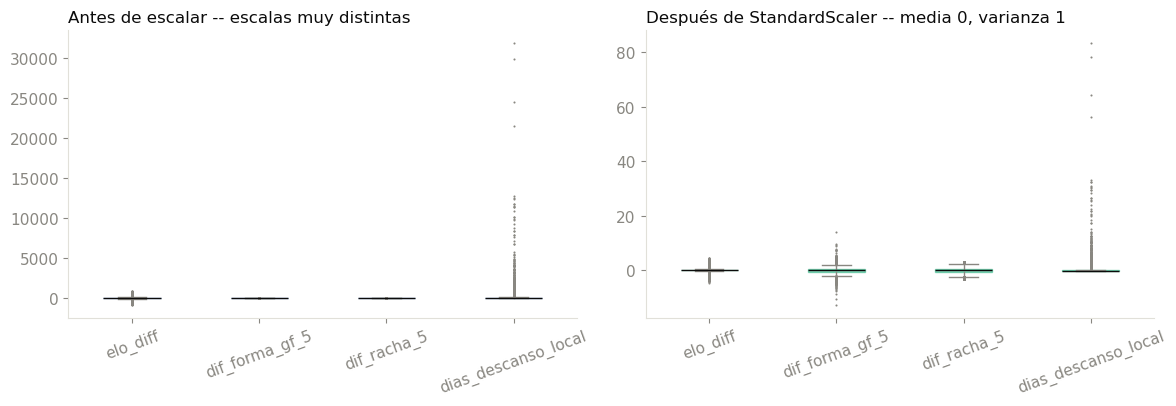

In [7]:
from sklearn.preprocessing import StandardScaler

FEATURES_EJEMPLO = ["elo_diff", "dif_forma_gf_5", "dif_racha_5", "dias_descanso_local"]
X_ejemplo = df_jugados[FEATURES_EJEMPLO].dropna()
X_escalado = pd.DataFrame(StandardScaler().fit_transform(X_ejemplo), columns=FEATURES_EJEMPLO)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.boxplot([X_ejemplo[c] for c in FEATURES_EJEMPLO], tick_labels=FEATURES_EJEMPLO,
           patch_artist=True, boxprops=dict(facecolor=AZUL, alpha=0.5, edgecolor=AZUL),
           medianprops=dict(color=TINTA), whiskerprops=dict(color=GRIS), capprops=dict(color=GRIS),
           flierprops=dict(marker=".", markersize=3, markerfacecolor=GRIS, markeredgecolor="none"))
ax.set_title("Antes de escalar -- escalas muy distintas", loc="left", fontsize=12, color=TINTA)
ax.tick_params(axis="x", rotation=20)
limpiar_ejes(ax)

ax = axes[1]
ax.boxplot([X_escalado[c] for c in FEATURES_EJEMPLO], tick_labels=FEATURES_EJEMPLO,
           patch_artist=True, boxprops=dict(facecolor=AQUA, alpha=0.5, edgecolor=AQUA),
           medianprops=dict(color=TINTA), whiskerprops=dict(color=GRIS), capprops=dict(color=GRIS),
           flierprops=dict(marker=".", markersize=3, markerfacecolor=GRIS, markeredgecolor="none"))
ax.set_title("Después de StandardScaler -- media 0, varianza 1", loc="left", fontsize=12, color=TINTA)
ax.tick_params(axis="x", rotation=20)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

## 5. Validar los supuestos antes de modelar

Dos preguntas que hay que responder con datos, no dar por hecho, antes de elegir Poisson
como familia de distribución y antes de decidir cuánto histórico usar:

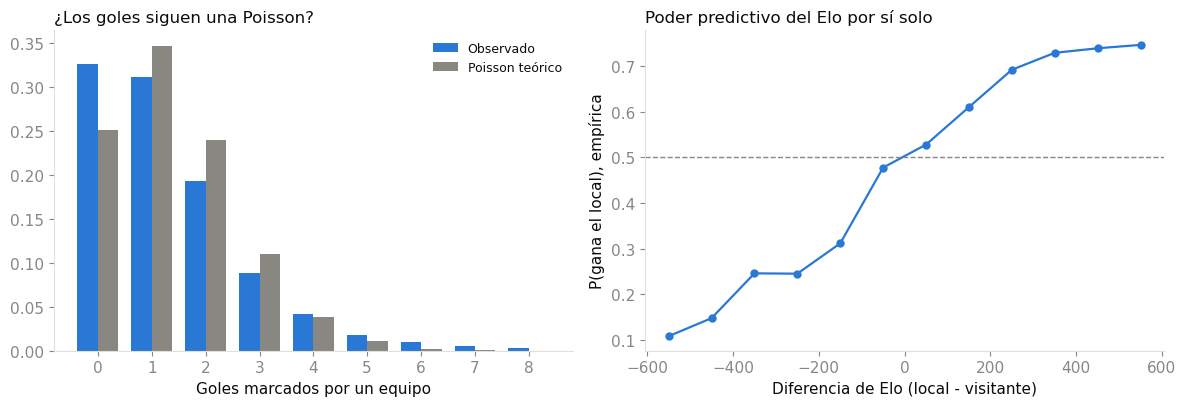

Media de goles por equipo y partido (desde 1990): 1.380  |  Varianza: 2.460 (sobredispersión: 1.78x sobre lo que pediría una Poisson pura)


In [8]:
df_moderno = df_jugados[df_jugados["fecha"] >= "1990-01-01"]
goles = pd.concat([df_moderno["goles_local"], df_moderno["goles_visitante"]])

max_goles_grafico = 8
observado = goles.value_counts(normalize=True).reindex(range(max_goles_grafico + 1), fill_value=0)
teorico = poisson.pmf(range(max_goles_grafico + 1), goles.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
x = np.arange(max_goles_grafico + 1)
ancho = 0.38
ax.bar(x - ancho / 2, observado.values, width=ancho, color=AZUL, label="Observado")
ax.bar(x + ancho / 2, teorico, width=ancho, color=GRIS, label="Poisson teórico")
ax.set_xticks(x)
ax.set_xlabel("Goles marcados por un equipo")
ax.set_title("¿Los goles siguen una Poisson?", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
limpiar_ejes(ax)

# --- Poder predictivo del Elo: probabilidad empírica de victoria por bins de elo_diff ---
ax = axes[1]
bins_elo = pd.cut(df_moderno["elo_diff"], bins=np.linspace(-600, 600, 13))
prob_victoria_local = (df_moderno["resultado_1x2"] == "LOCAL").groupby(bins_elo, observed=True).mean()
centros = [b.mid for b in prob_victoria_local.index]
ax.plot(centros, prob_victoria_local.values, "o-", color=AZUL, linewidth=1.6, markersize=5)
ax.axhline(0.5, color=GRIS, linewidth=1, linestyle="--")
ax.set_xlabel("Diferencia de Elo (local - visitante)")
ax.set_ylabel("P(gana el local), empírica")
ax.set_title("Poder predictivo del Elo por sí solo", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"Media de goles por equipo y partido (desde 1990): {goles.mean():.3f}  |  Varianza: {goles.var():.3f} "
      f"(sobredispersión: {goles.var()/goles.mean():.2f}x sobre lo que pediría una Poisson pura)")

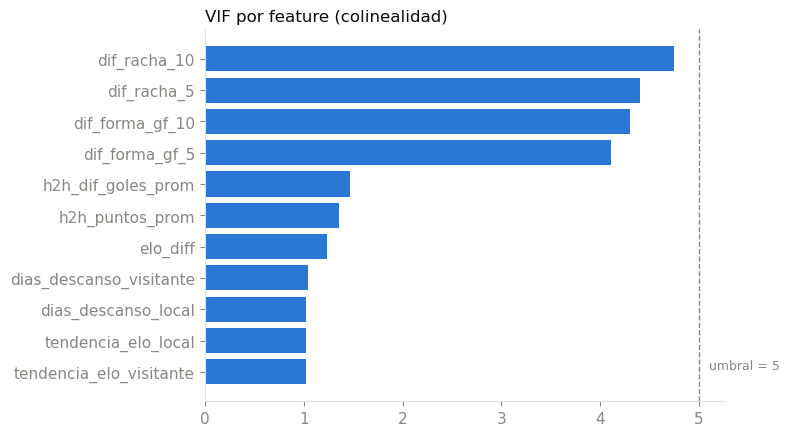

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

FEATURES_VIF = [
    "elo_diff", "tendencia_elo_local", "tendencia_elo_visitante",
    "dif_forma_gf_5", "dif_forma_gf_10", "dif_racha_5", "dif_racha_10",
    "dias_descanso_local", "dias_descanso_visitante",
    "h2h_puntos_prom", "h2h_dif_goles_prom",
]
X_vif = df_moderno[FEATURES_VIF].dropna().astype(float)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=FEATURES_VIF,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colores_vif = [ROJO if v > 5 else AZUL for v in vif.values]
ax.barh(vif.index, vif.values, color=colores_vif)
ax.axvline(5, color=GRIS, linewidth=1, linestyle="--")
ax.text(5.1, 0, "umbral = 5", color=GRIS, fontsize=9, va="bottom")
ax.set_title("VIF por feature (colinealidad)", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 6. Elegir el modelo con evidencia, no con un solo torneo

Comparar GLM, LightGBM y XGBoost solo contra el Mundial 2026 no basta: un bootstrap sobre
esos 72 partidos da un intervalo de confianza de RMSE más ancho que la diferencia real entre
familias. Por eso la comparación se repite contra **5 Mundiales** (2010, 2014, 2018, 2022 y
2026), reentrenando cada vez solo con datos anteriores al inicio de ese torneo.

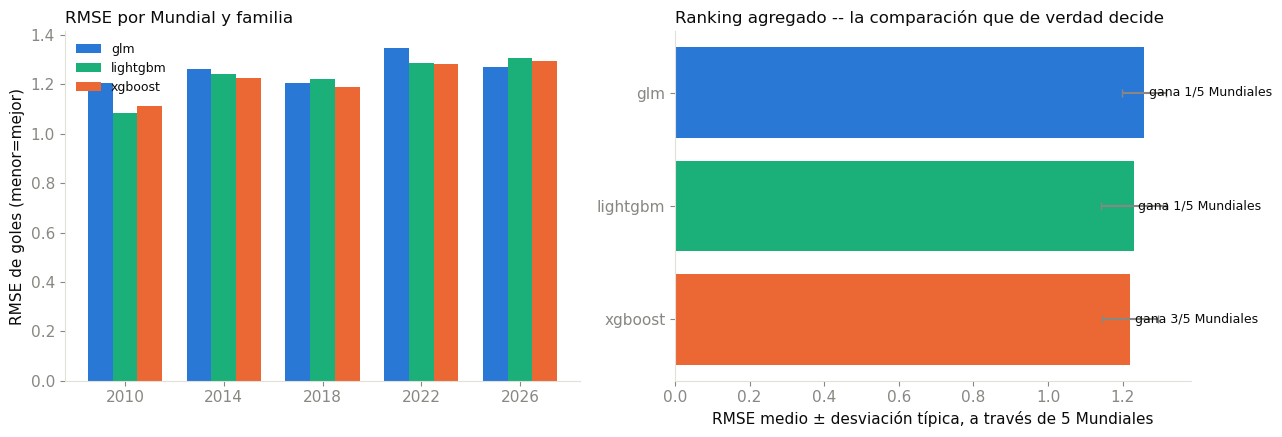

Familia con mejor RMSE medio a través de los 5 Mundiales: xgboost (1.2201 ± 0.0748, gana 3/5)


In [10]:
df_comparacion = pd.read_csv(DIR_RESULTS / "comparacion_modelos.csv")
df_resumen = pd.read_csv(DIR_RESULTS / "comparacion_resumen.csv").sort_values("rmse_medio")

COLOR_FAMILIA = {"glm": AZUL, "lightgbm": AQUA, "xgboost": NARANJA}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- RMSE por Mundial y familia ---
ax = axes[0]
mundiales = sorted(df_comparacion["mundial"].unique())
familias = list(COLOR_FAMILIA.keys())
ancho = 0.25
x = np.arange(len(mundiales))
for i, familia in enumerate(familias):
    valores = df_comparacion[df_comparacion["familia"] == familia].set_index("mundial").loc[mundiales, "rmse"]
    ax.bar(x + (i - 1) * ancho, valores.values, width=ancho, color=COLOR_FAMILIA[familia], label=familia)
ax.set_xticks(x)
ax.set_xticklabels(mundiales)
ax.set_ylabel("RMSE de goles (menor=mejor)")
ax.set_title("RMSE por Mundial y familia", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
limpiar_ejes(ax)

# --- Ranking agregado con barra de error (std) ---
ax = axes[1]
colores_resumen = [COLOR_FAMILIA[f] for f in df_resumen["familia"]]
ax.barh(df_resumen["familia"], df_resumen["rmse_medio"], xerr=df_resumen["rmse_std"],
        color=colores_resumen, error_kw=dict(ecolor=GRIS, capsize=3))
for i, (familia, rmse, veces) in enumerate(zip(df_resumen["familia"], df_resumen["rmse_medio"], df_resumen["veces_gana"])):
    ax.text(rmse + df_resumen["rmse_std"].max() * 0.15, i, f"gana {veces}/5 Mundiales",
            va="center", fontsize=9, color=TINTA)
ax.set_xlabel("RMSE medio ± desviación típica, a través de 5 Mundiales")
ax.set_title("Ranking agregado -- la comparación que de verdad decide", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

ganador = df_resumen.iloc[0]
nombre_g, rmse_g, std_g, veces_g = ganador["familia"], ganador["rmse_medio"], ganador["rmse_std"], ganador["veces_gana"]
print(f"Familia con mejor RMSE medio a través de los 5 Mundiales: {nombre_g} "
      f"({rmse_g:.4f} ± {std_g:.4f}, gana {veces_g}/5)")

## 7. Calibración: cuando el modelo dice 70%, ¿acierta el 70% de las veces?

Un modelo bien calibrado no solo tiene que acertar el ganador -- cuando dice "70% de
probabilidad", eso debería cumplirse aproximadamente el 70% de las veces entre todos los
partidos donde dijo eso. Se compara sobre TODOS los partidos ya jugados del Mundial 2026
(fase de grupos + dieciseisavos).

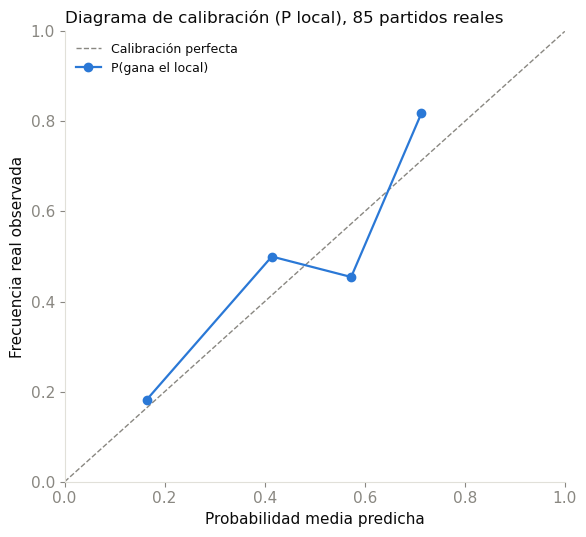

In [11]:
df_grupos_pred = pd.read_csv(DIR_RESULTS / "predicciones_fase_grupos.csv")
df_elim_pred = pd.read_csv(DIR_RESULTS / "predicciones_eliminatoria.csv")

def diagrama_calibracion(ax, prob_predicha, acierto, color, etiqueta, n_bins=4):
    bins = pd.qcut(prob_predicha, n_bins, duplicates="drop")
    resumen = pd.DataFrame({"prob": prob_predicha, "acierto": acierto, "bin": bins}).groupby("bin", observed=True).agg(
        prob_media=("prob", "mean"), frecuencia_real=("acierto", "mean"), n=("acierto", "size"))
    ax.plot(resumen["prob_media"], resumen["frecuencia_real"], "o-", color=color, linewidth=1.6, markersize=6, label=etiqueta)
    return resumen


prob_local = pd.concat([df_grupos_pred["prob_local"], df_elim_pred["prob_local"]], ignore_index=True)
acierto_local = pd.concat([
    df_grupos_pred["resultado_1x2_real"] == "LOCAL",
    df_elim_pred["resultado_1x2_real"] == "LOCAL",
], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], "--", color=GRIS, linewidth=1, label="Calibración perfecta")
diagrama_calibracion(ax, prob_local, acierto_local, AZUL, "P(gana el local)")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Frecuencia real observada")
ax.set_title("Diagrama de calibración (P local), 85 partidos reales", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 8. Precisión real hasta hoy, contra una baseline honesta

No basta con un número suelto -- hay que compararlo contra "predecir siempre lo más
probable a priori" (baseline ingenua), o cualquier acierto por encima del 50% suena mejor de
lo que es.

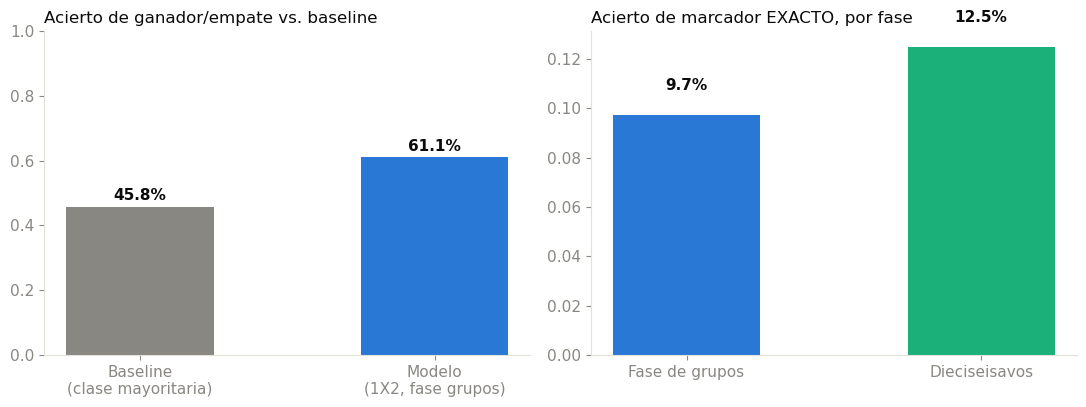

In [12]:
acierto_1x2_grupos = (df_grupos_pred["resultado_1x2_previsto"] == df_grupos_pred["resultado_1x2_real"]).mean()
acierto_marcador_grupos = (df_grupos_pred["marcador_previsto"] == df_grupos_pred["marcador_real"]).mean()
acierto_marcador_elim = (df_elim_pred["marcador_previsto"] == df_elim_pred["marcador_real_90min"]).mean()

baseline_ingenua = df_grupos_pred["resultado_1x2_real"].value_counts(normalize=True).max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
etiquetas = ["Baseline\n(clase mayoritaria)", "Modelo\n(1X2, fase grupos)"]
valores = [baseline_ingenua, acierto_1x2_grupos]
ax.bar(etiquetas, valores, color=[GRIS, AZUL], width=0.5)
for i, v in enumerate(valores):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold", color=TINTA)
ax.set_ylim(0, 1)
ax.set_title("Acierto de ganador/empate vs. baseline", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

ax = axes[1]
etiquetas2 = ["Fase de grupos", "Dieciseisavos"]
valores2 = [acierto_marcador_grupos, acierto_marcador_elim]
ax.bar(etiquetas2, valores2, color=[AZUL, AQUA], width=0.5)
for i, v in enumerate(valores2):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold", color=TINTA)
ax.set_title("Acierto de marcador EXACTO, por fase", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

## 9. ¿Qué mira el modelo? Importancia de features (XGBoost)

Útil para desconfiar de un modelo que "acierta pero por razones raras" -- estas son las
features que más reducen el error al construir los árboles.

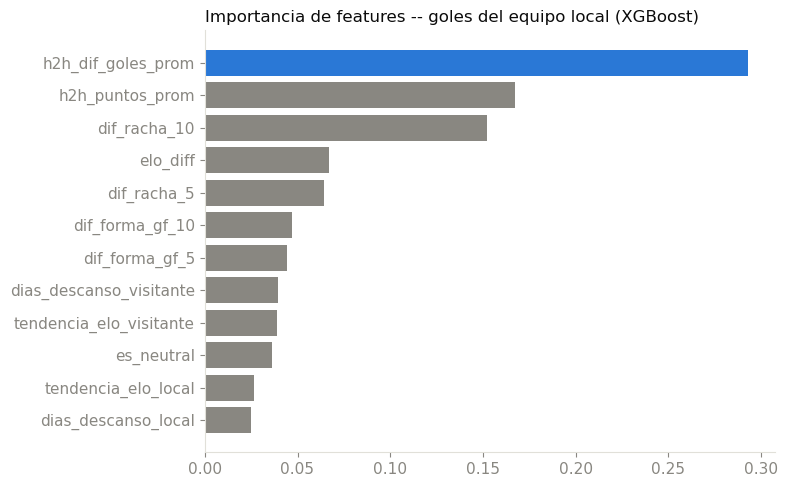

In [13]:
RUTA_CHECKPOINT_PRE_MUNDIAL = DIR_MODELOS / "checkpoints" / "pre_mundial"
modelo_local_pre = joblib.load(RUTA_CHECKPOINT_PRE_MUNDIAL / "modelo_goles_local.joblib")

FEATURES_MODELO = [
    "elo_diff", "tendencia_elo_local", "tendencia_elo_visitante",
    "dif_forma_gf_5", "dif_forma_gf_10", "dif_racha_5", "dif_racha_10",
    "dias_descanso_local", "dias_descanso_visitante",
    "es_neutral", "h2h_puntos_prom", "h2h_dif_goles_prom",
]

if hasattr(modelo_local_pre, "feature_importances_"):
    importancia = pd.Series(modelo_local_pre.feature_importances_, index=FEATURES_MODELO).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    colores_imp = [AZUL if v == importancia.max() else GRIS for v in importancia.values]
    ax.barh(importancia.index, importancia.values, color=colores_imp)
    ax.set_title("Importancia de features -- goles del equipo local (XGBoost)", loc="left", fontsize=12, color=TINTA)
    limpiar_ejes(ax)
    plt.tight_layout()
    plt.show()
else:
    print(f"El checkpoint pre_mundial es de familia '{type(modelo_local_pre).__name__}', "
          f"sin feature_importances_ directo (p.ej. un GLM) -- esta sección solo aplica a modelos de árboles.")

## 10. Probabilidades por selección (Montecarlo, con lo jugado hasta hoy)

3.000 simulaciones completas del cuadro, con el checkpoint más reciente y los resultados ya
jugados fijados como conocidos -- no se "recalcula" lo que ya pasó, solo se propaga la
incertidumbre de lo que queda por decidir.

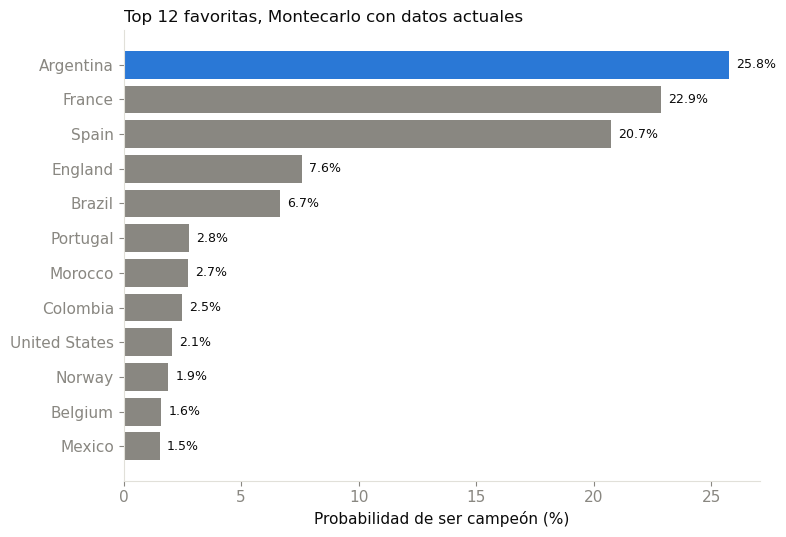

In [14]:
df_prob = pd.read_csv(DIR_RESULTS / "simulacion_probabilidades_actual.csv")
top_n = 12
top_equipos = df_prob.sort_values("campeon", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(8, 5.5))
colores_ranking = [AZUL] + [GRIS] * (len(top_equipos) - 1)
ax.barh(top_equipos["seleccion"][::-1], top_equipos["campeon"][::-1] * 100, color=colores_ranking[::-1])
for i, v in enumerate(top_equipos["campeon"][::-1] * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color=TINTA)
ax.set_xlabel("Probabilidad de ser campeón (%)")
ax.set_title(f"Top {top_n} favoritas, Montecarlo con datos actuales", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

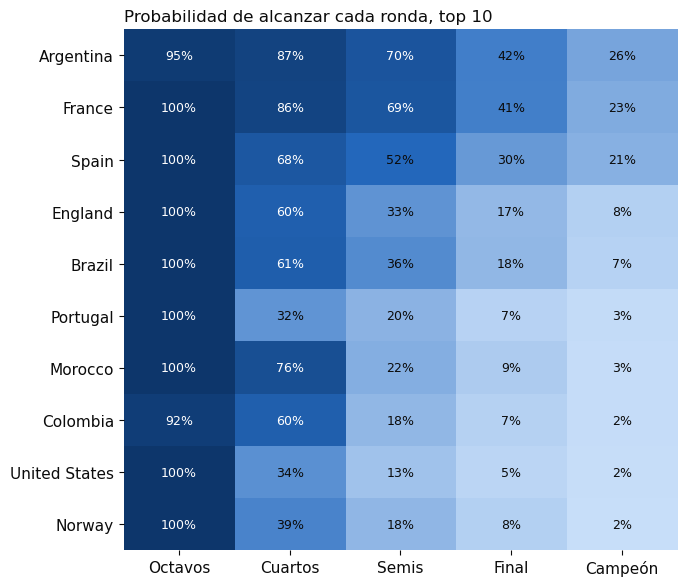

In [15]:
ETAPAS_MOSTRAR = ["alcanza_octavos", "alcanza_cuartos", "alcanza_semis", "alcanza_final", "campeon"]
ETIQUETAS_ETAPAS = ["Octavos", "Cuartos", "Semis", "Final", "Campeón"]

matriz = df_prob.sort_values("campeon", ascending=False).head(10).set_index("seleccion")[ETAPAS_MOSTRAR]

from matplotlib.colors import LinearSegmentedColormap
CMAP_SECUENCIAL = LinearSegmentedColormap.from_list("azul_secuencial", ["#cde2fb", "#256abf", "#0d366b"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz.values, cmap=CMAP_SECUENCIAL, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ETIQUETAS_ETAPAS)))
ax.set_xticklabels(ETIQUETAS_ETAPAS)
ax.set_yticks(range(len(matriz.index)))
ax.set_yticklabels(matriz.index)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        valor = matriz.values[i, j]
        color_texto = "white" if valor > 0.55 else TINTA
        ax.text(j, i, f"{valor:.0%}", ha="center", va="center", fontsize=9, color=color_texto)
ax.set_title("Probabilidad de alcanzar cada ronda, top 10", loc="left", fontsize=12, color=TINTA)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## 11. El cuadro final

Cascada determinista (una sola predicción por cruce, no miles de simulaciones): real donde
ya se jugó, predicho con el modelo más reciente para el resto. Página completa e interactiva
en `results/bracket.html`.

In [16]:
df_cuadro = pd.read_csv(DIR_RESULTS / "cuadro_completo.csv")
campeon_previsto = df_cuadro.loc[df_cuadro["num_partido"] == 104, "ganador"].iloc[0]
finalistas = df_cuadro.loc[df_cuadro["num_partido"] == 104, ["equipo_a", "equipo_b"]].iloc[0]

print(f"Final prevista: {finalistas['equipo_a']} vs {finalistas['equipo_b']}")
print(f"Campeón previsto: {campeon_previsto}")
print(f"\nCuadro completo (partido a partido): {DIR_RESULTS / 'cuadro_completo.csv'}")
print(f"Visualización interactiva: {DIR_RESULTS / 'bracket.html'}")
df_cuadro[["ronda", "equipo_a", "equipo_b", "marcador", "ganador", "jugado"]].tail(8)

Final prevista: Spain vs Argentina
Campeón previsto: Spain

Cuadro completo (partido a partido): /Users/danielcanteragomez/portfolio/wc-2026-match-predictor/results/cuadro_completo.csv
Visualización interactiva: /Users/danielcanteragomez/portfolio/wc-2026-match-predictor/results/bracket.html


,ronda,equipo_a,equipo_b,marcador,ganador,jugado
24,Cuartos de final,France,Morocco,1-0,France,False
25,Cuartos de final,Spain,Belgium,2-0,Spain,False
26,Cuartos de final,Brazil,England,1-1,Brazil,False
27,Cuartos de final,Argentina,Colombia,1-0,Argentina,False
28,Semifinales,France,Spain,1-1,Spain,False
29,Semifinales,Brazil,Argentina,1-1,Argentina,False
30,Tercer puesto,France,Brazil,1-1,France,False
31,Final,Spain,Argentina,1-1,Spain,False


## 12. Conclusiones y próximos pasos

**Lo que funciona bien**:
- Reentrenamiento walk-forward honesto: cada ronda se evalúa con el modelo tal como estaba
  ANTES de conocer su resultado, nunca al revés.
- La elección de familia de modelo (XGBoost) se apoya en evidencia de 5 Mundiales, no en un
  solo torneo -- un bootstrap sobre un único torneo daba un intervalo de confianza más ancho
  que la diferencia real entre familias.
- Tests que extraen y comprueban las funciones reales de los notebooks (no reimplementadas
  aparte), cubriendo justo los bugs matemáticos más sutiles que se encontraron por el camino.

**Limitaciones conocidas, de más a menos impacto**:
1. **El techo está en los datos, no en el modelo**: Elo + forma + descanso + h2h no incluye
   bajas de jugadores, valor de plantilla, ni cuotas de casas de apuestas (el baseline
   estándar en toda la literatura de predicción de fútbol, y ausente aquí).
2. **Dixon-Coles es un parche de 1997** que solo corrige 4 celdas de la rejilla de
   marcadores -- un Poisson bivariante (Karlis & Ntzoufras) modelaría la correlación real
   entre ambos marcadores en toda la rejilla, no solo en los bajos.
3. El empate es el resultado estructuralmente más difícil (~23% de los casos): depende de
   que dos Poisson caigan exactamente igual, y ningún ajuste actual lo trata como una clase
   distinta a propósito.
4. La comparación de familias re-tunea hiperparámetros una sola vez por CV, sin repetir con
   distintas semillas -- no se ha medido cuánta varianza aporta la propia búsqueda de
   hiperparámetros.

Este notebook es autocontenido: para reproducirlo fuera de este repositorio basta con subir
`data/processed/partidos_features.csv`, `data/raw/results.csv`, la carpeta `results/` y
`models/checkpoints/pre_mundial/` como dataset adjunto, y ajustar `DIR_DATOS` en la primera
celda.